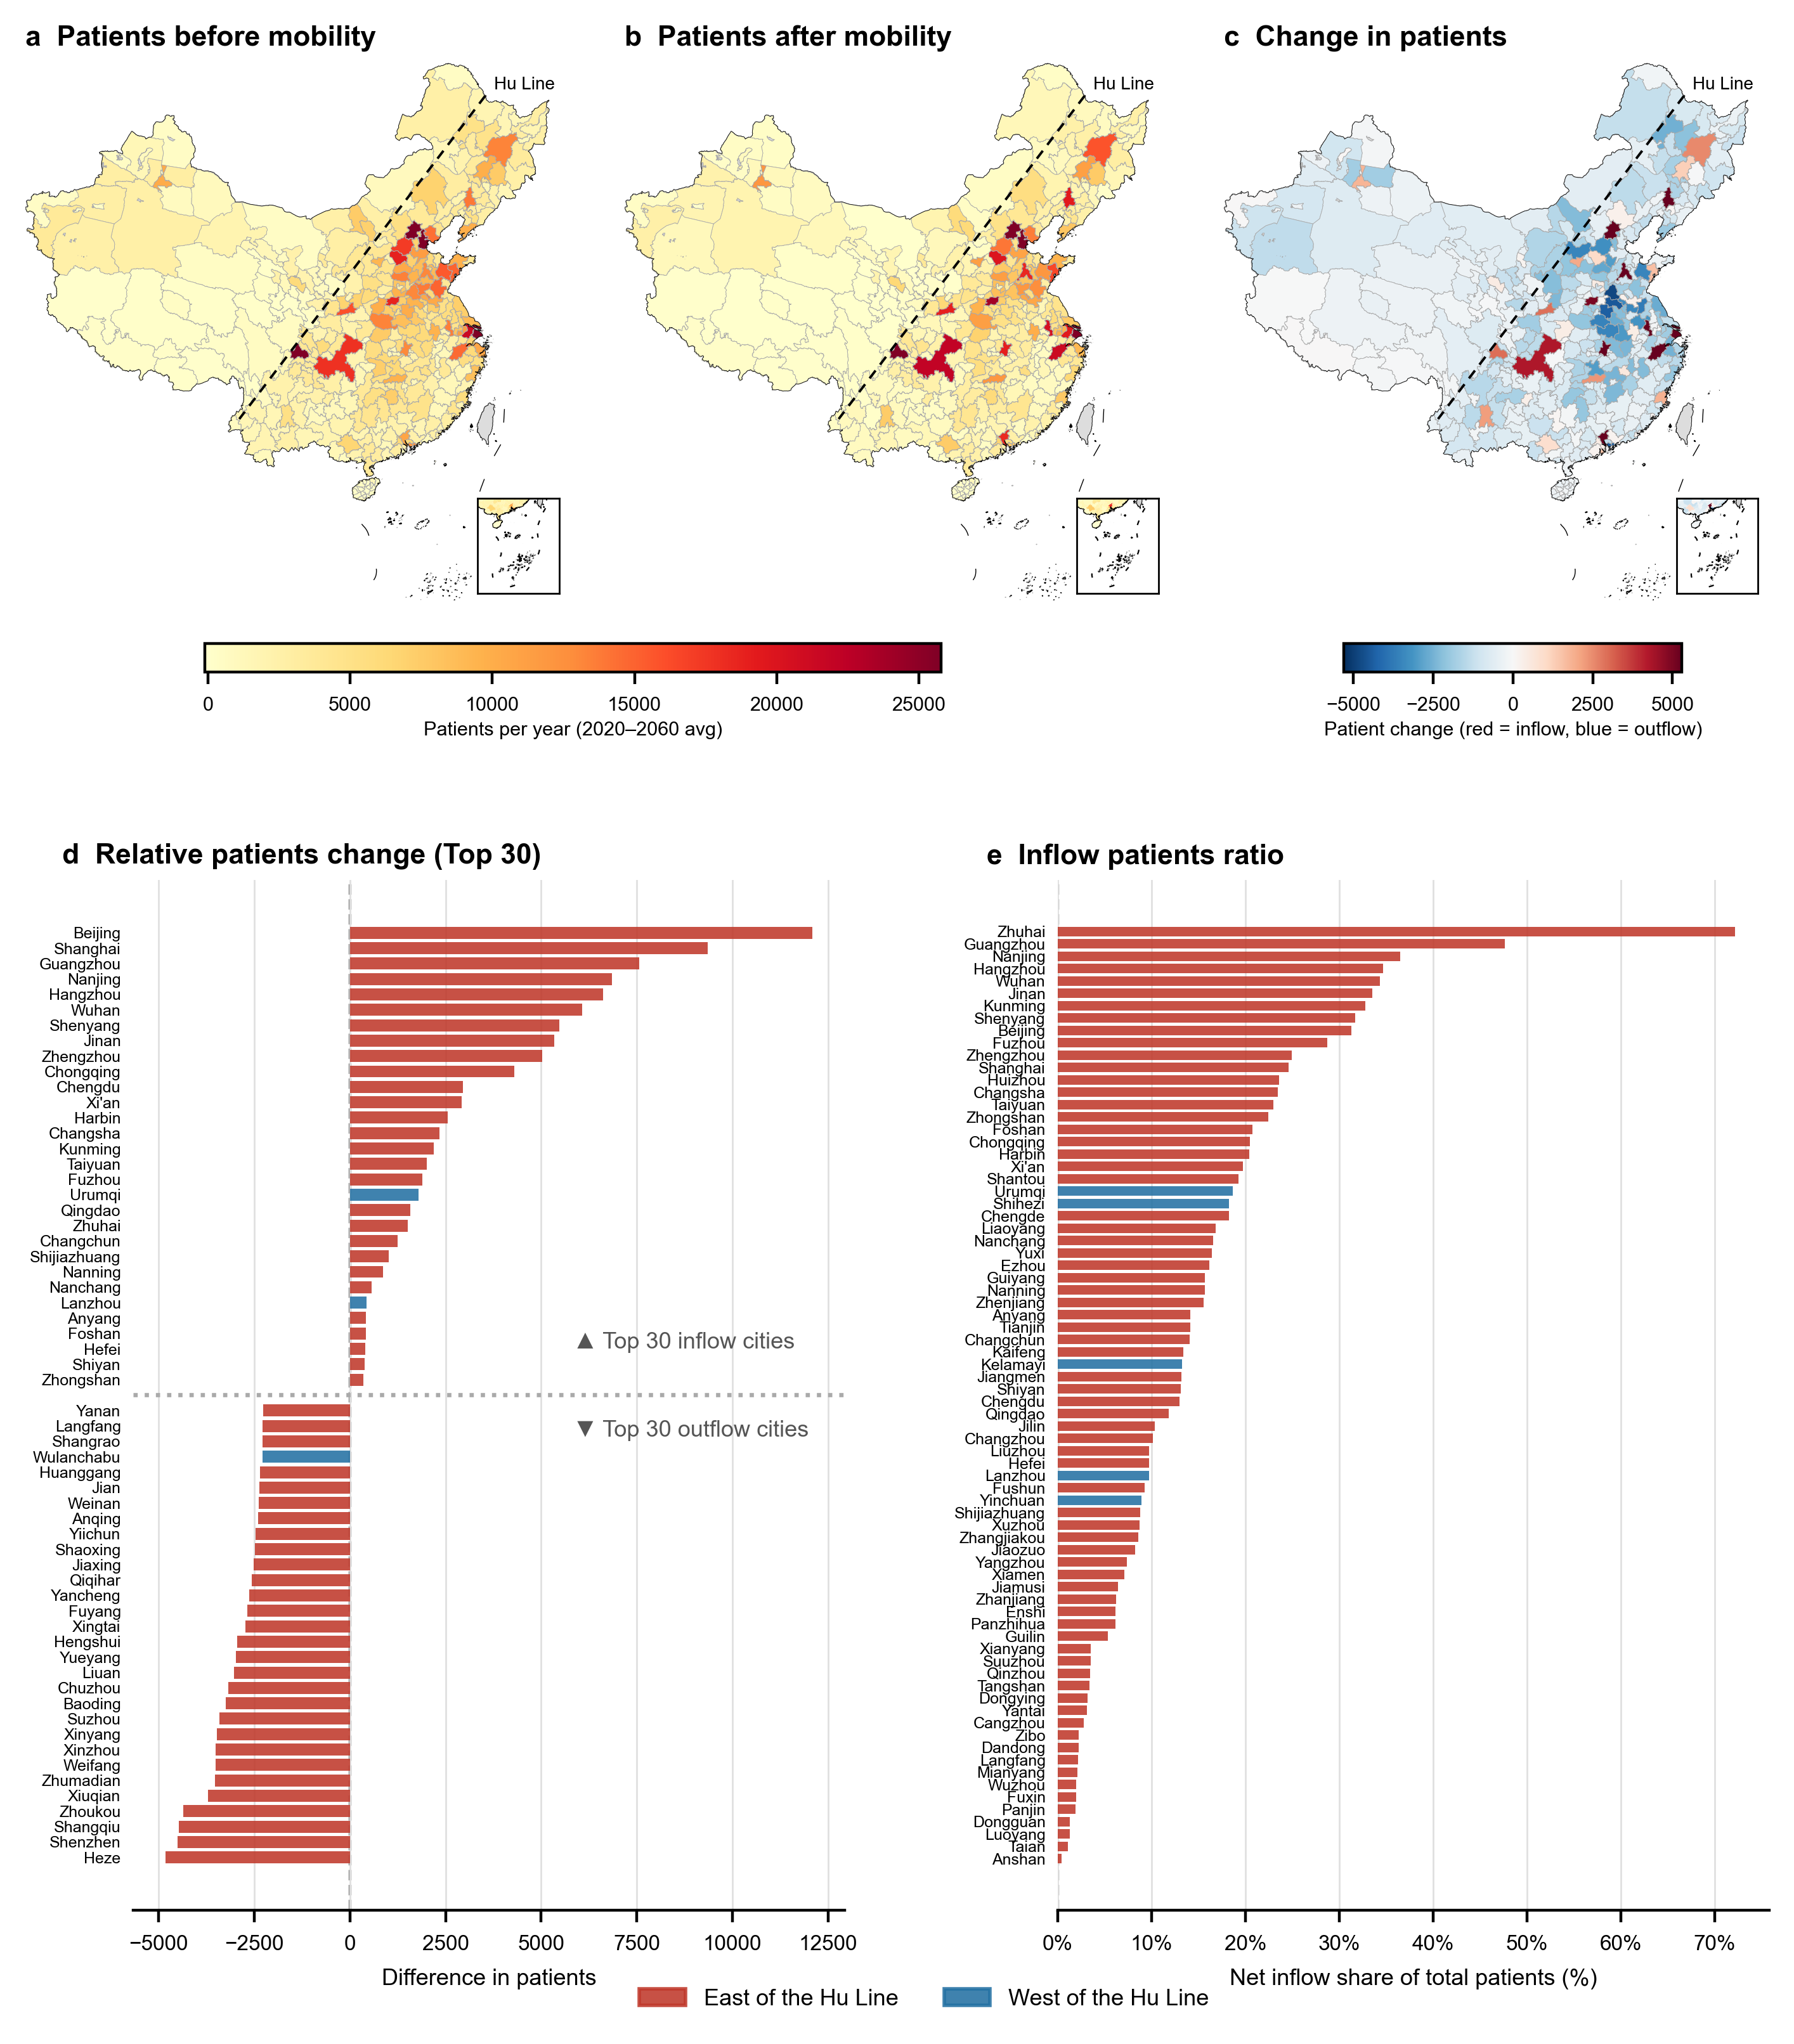

Saved → /Users/shirley/Desktop/plots_V2/Fig3.png


In [ ]:
# =============================================================================
# Fig3: 3 choropleth maps + 2 diverging bar charts
# Maps: before mobility / after mobility / patient change (demand - mo_total)
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import box as shapely_box
from pyproj import Transformer
from adjustText import adjust_text

# ── 0. Paths & settings ───────────────────────────────────────────────────────
FLOW_DIR   = Path("/Volumes/UCL/论文工作/空气污染/cross_flow_truncated/averaged_results/flow_avg")
LOCAL_DIR  = Path("/Volumes/UCL/论文工作/空气污染/health_burden/air_scenarios_5/city_patient_sum")
SHP_PATH   = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/city_shp/shi_en.shp")
CHINA_SHP  = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国底图-中图社审过版本/中国底图/中国面.shp")
CHINA_SHP2 = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国国界线/九段线/九段线和群岛.shp")
OUTFILE    = Path("/Users/shirley/Desktop/plots_V2/Fig3.png")
SCENARIO   = "earlypeak_NZ_CL"
YEARS      = [2020, 2030, 2040, 2050, 2060]

CITY_NAME_MAP = {
    "Wulumuqi":  "Urumqi",
    "Xian":      "Xi'an",
    "Qiqihaer":  "Qiqihar",
    "Huhehaote": "Hohhot",
    "Haerbin":   "Harbin",
}

C_EAST   = "#C0392B"
C_WEST   = "#2471A3"
PROJ_STR = "+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105"

# ── 1. Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        6,
    "axes.titlesize":   8,
    "axes.titleweight": "bold",
    "axes.titlepad":    2,
})

# ── 2. Spatial data ───────────────────────────────────────────────────────────
china_border = gpd.read_file(CHINA_SHP).to_crs(PROJ_STR)
jiudanline   = gpd.read_file(CHINA_SHP2).to_crs(PROJ_STR)

city_shp_raw = gpd.read_file(SHP_PATH)
city_shp_raw["English"] = city_shp_raw["English"].str.strip().map(
    lambda x: CITY_NAME_MAP.get(x, x))
city_shp = city_shp_raw.to_crs(PROJ_STR)

_hhy_transformer = Transformer.from_crs("EPSG:4326", PROJ_STR, always_xy=True)
_HHY_X, _HHY_Y  = _hhy_transformer.transform([127.5, 98.5], [50.2, 25.0])

_NANHAI_BOUNDS = (
    gpd.GeoDataFrame(geometry=[shapely_box(105, 2, 122, 24)], crs="EPSG:4326")
    .to_crs(PROJ_STR).total_bounds
)

_hhy_x0, _hhy_y0 = _HHY_X[0], _HHY_Y[0]
_hhy_x1, _hhy_y1 = _HHY_X[1], _HHY_Y[1]

def _hhy_x_at_y(y):
    t = (y - _hhy_y1) / (_hhy_y0 - _hhy_y1)
    return _hhy_x1 + t * (_hhy_x0 - _hhy_x1)

_cx = city_shp.geometry.centroid.x
_cy = city_shp.geometry.centroid.y
city_shp["region"] = np.where(_cx > _hhy_x_at_y(_cy), "East", "West")

region_map = (
    city_shp[["English", "region"]]
    .drop_duplicates(subset="English")
    .set_index("English")["region"]
    .to_dict()
)

# ── 3. Data loaders ───────────────────────────────────────────────────────────
def rename_idx(idx):
    return idx.str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))

def load_flow_matrix(year):
    path = FLOW_DIR / f"flow_patientnum_avg_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path, index_col=0)
    df.index   = rename_idx(df.index)
    df.columns = rename_idx(df.columns)
    df = df.loc[~df.index.isin(["total"]), ~df.columns.isin(["total"])]
    np.fill_diagonal(df.values, 0)
    return df

def load_citysum(year):
    path = LOCAL_DIR / f"citysum_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path)
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    return df.groupby("city")[["local_patient", "mo_total"]].sum()

def compute_year(year):
    df_flow  = load_flow_matrix(year)
    df_local = load_citysum(year)
    inflow   = df_flow.sum(axis=0).groupby(level=0).sum()
    outflow  = df_flow.sum(axis=1).groupby(level=0).sum()
    all_cities = inflow.index.union(outflow.index)
    inflow   = inflow.reindex(all_cities,  fill_value=0)
    outflow  = outflow.reindex(all_cities, fill_value=0)
    net      = (inflow - outflow).rename("net")
    df_local = df_local.groupby(level=0).sum()
    common   = net.index.intersection(df_local.index)
    out      = df_local.loc[common].copy()
    out["net"]    = net.loc[common].values
    out["demand"] = out["net"] + out["local_patient"]
    return out

# ── 4. Compute averages ───────────────────────────────────────────────────────
frames = [compute_year(y) for y in YEARS]
avg    = pd.concat(frames).groupby(level=0).mean()

avg["diff"]        = avg["demand"] - avg["mo_total"]   # patient change
avg["net_local_r"] = avg["net"] / avg["demand"]
avg["region"]      = avg.index.map(region_map)

df_diff  = avg.sort_values("diff", ascending=False).copy()
df_ratio = (
    avg[avg["net"] > 0]
    .sort_values("net_local_r", ascending=False)
    .copy()
)

# ── 5. Merge with shapefile ───────────────────────────────────────────────────
avg_reset = (
    avg[["demand", "mo_total", "diff", "net_local_r", "region"]]
    .reset_index()
    .rename(columns={avg.index.name if avg.index.name else "index": "city"})
)
shp = city_shp.merge(avg_reset, left_on="English", right_on="city", how="left")

LABEL_THRESH = 20000

# ── 6. Nanhai inset helper ────────────────────────────────────────────────────
def _add_nanhai_inset(parent_ax, shp, col, norm, cmap):
    x1, y1, x2, y2 = _NANHAI_BOUNDS
    axins = parent_ax.inset_axes([0.83, 0.01, 0.15, 0.18])
    axins.set_facecolor("white")
    shp.plot(column=col, ax=axins, cmap=cmap, norm=norm,
             linewidth=0, missing_kwds={"color": "lightgrey"})
    china_border.plot(ax=axins, facecolor="none", edgecolor="black", linewidth=0.2)
    jiudanline.plot(ax=axins, edgecolor="black", linewidth=0.4)
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in axins.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("black")

# ── 7. Map drawing helpers ────────────────────────────────────────────────────
def _map_base(ax, col, norm, cmap, title, panel):
    """Draw base map layers shared by all three maps."""
    shp.plot(column=col, ax=ax, cmap=cmap, norm=norm,
             linewidth=0.15, edgecolor="#AAAAAA",
             missing_kwds={"color": "#DDDDDD"})
    china_border.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.15)
    jiudanline.plot(ax=ax, edgecolor="black", linewidth=0.25)
    ax.plot(_HHY_X, _HHY_Y, color="black", linewidth=0.7,
            linestyle="--", dashes=(4, 3), zorder=5)
    ax.text(_HHY_X[0] + 80000, _HHY_Y[0] + 60000,
            "Hu Line", fontsize=5, color="black", zorder=5)
    xmin, ymin, xmax, ymax = china_border.total_bounds
    height = ymax - ymin
    width  = xmax - xmin
    ax.set_xlim(xmin, xmax + width * 0.04)   # extra 4% padding on the right
    ax.set_ylim(ymin + height * 0.10, ymax + height * 0.01)
    ax.set_axis_off()
    ax.text(-0, 1.01, f"{panel}  {title}",
            transform=ax.transAxes,
            fontsize=8, fontweight="bold",
            va="bottom", ha="left")
    _add_nanhai_inset(ax, col, norm, cmap)

def draw_map(ax, col, title, panel, label_col=None):
    """Standard map (YlOrRd) with optional city labels."""
    norm = Normalize(vmin=vmin_map, vmax=vmax_map)
    cmap = "YlOrRd"
    _map_base(ax, col, norm, cmap, title, panel)
    if label_col:
        labeled = shp[shp[label_col] > LABEL_THRESH].copy()
        texts = []
        for _, row in labeled.iterrows():
            cx_r = row.geometry.centroid.x
            cy_r = row.geometry.centroid.y
            val  = row[label_col]


def draw_diff_map(ax, title, panel):
    """Diverging map for patient change (demand - mo_total)."""
    dmax  = shp["diff"].abs().quantile(0.98)
    norm  = TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)
    cmap  = "RdBu_r"   # red = net inflow, blue = net outflow
    _map_base(ax, "diff", norm, cmap, title, panel)

    # Label top 3 inflow and top 3 outflow cities
    top3_in  = shp.nlargest(3,  "diff").dropna(subset=["diff"])
    top3_out = shp.nsmallest(3, "diff").dropna(subset=["diff"])
    label_cities = pd.concat([top3_in, top3_out])

    texts = []
    for _, row in label_cities.iterrows():
        if pd.isna(row.geometry):
            continue
        cx_r = row.geometry.centroid.x
        cy_r = row.geometry.centroid.y
        val  = row["diff"]
        name = row["English"]

    return norm, cmap

# ── 8. Shared norm for maps a & b ────────────────────────────────────────────
vmin_map = min(shp["mo_total"].quantile(0.01), shp["demand"].quantile(0.01))
vmax_map = max(shp["mo_total"].quantile(0.99), shp["demand"].quantile(0.99))

# ── 9. Layout: 3 maps (top row) + 2 bar charts (bottom) ─────────────────────
fig = plt.figure(figsize=(18 / 2.54, 24 / 2.54), dpi=400, facecolor="white")

# Top row: 3 maps
gs_maps = GridSpec(
    1, 3,
    figure=fig,
    hspace=0.0, wspace=0.10,
    left=0, right=0.97,
    top=0.97,   bottom=0.45,
)
ax_mapA = fig.add_subplot(gs_maps[0, 0])
ax_mapB = fig.add_subplot(gs_maps[0, 1])
ax_mapC = fig.add_subplot(gs_maps[0, 2])

# Bottom: 2 bar charts with 2:1 width ratio
gs_bars = GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[1, 1],           # barC twice as wide as barD
    hspace=0.0, wspace=0.30,
    left=0.06, right=0.97,
    top=0.48,   bottom=0.05,
)
ax_barC = fig.add_subplot(gs_bars[0, 0])
ax_barD = fig.add_subplot(gs_bars[0, 1])

# ── 10. Draw maps ─────────────────────────────────────────────────────────────
draw_map(ax_mapA, "mo_total", "Patients before mobility", "a",
         label_col="mo_total")
draw_map(ax_mapB, "demand",   "Patients after mobility",  "b",
         label_col="demand")
norm_diff, cmap_diff = draw_diff_map(ax_mapC,
    "Change in patients", "c")

# ── 11. Colorbars: manually positioned for equal width ────────────────────────
fig.canvas.draw()   # force render to get accurate axes positions
pos_a = ax_mapA.get_position()
pos_b = ax_mapB.get_position()
pos_c = ax_mapC.get_position()

cbar_h      = 0.012
cbar_bottom = pos_a.y0-0.03   # same vertical position for both colorbars

# Colorbar ab: spans ax_mapA left → ax_mapB right, same total width as two panels
cbar_ax_ab = fig.add_axes([
    pos_a.x0+0.1, cbar_bottom,
    pos_b.x1*0.8 - (pos_a.x0+0.1), cbar_h,
])
sm_ab = mcm.ScalarMappable(cmap="YlOrRd", norm=Normalize(vmin=vmin_map, vmax=vmax_map))
sm_ab.set_array([])
cbar_ab = fig.colorbar(sm_ab, cax=cbar_ax_ab, orientation="horizontal")
cbar_ab.ax.tick_params(labelsize=5.5)
cbar_ab.set_label("Patients per year (2020–2060 avg)", fontsize=5.5, labelpad=2)

# Colorbar c: exactly the width of ax_mapC
cbar_ax_c = fig.add_axes([
    pos_c.x0*1.1, cbar_bottom,
    pos_c.x1*0.95 - pos_c.x0*1.1 , cbar_h,
])
sm_c = mcm.ScalarMappable(cmap=cmap_diff, norm=norm_diff)
sm_c.set_array([])
cbar_c = fig.colorbar(sm_c, cax=cbar_ax_c, orientation="horizontal")
cbar_c.ax.tick_params(labelsize=5.5)
cbar_c.set_label("Patient change (red = inflow, blue = outflow)", fontsize=5.5, labelpad=2)

# ── 12. Bar style helper ──────────────────────────────────────────────────────
def style_bar(ax, title, xlabel):
    ax.text(-0.10, 1.01, title,
            transform=ax.transAxes,
            fontsize=8, fontweight="bold",
            va="bottom", ha="left")
    ax.set_xlabel(xlabel, fontsize=6.5)
    ax.axvline(0, color="#888", lw=0.8, ls="--", zorder=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=6.5)
    ax.tick_params(axis="x", labelsize=6)
    ax.grid(axis="x", color="#E0E0E0", lw=0.5, zorder=0)
    ax.set_facecolor("white")

# ── 13. Bar C ─────────────────────────────────────────────────────────────────
style_bar(ax_barC,
          "d  Relative patients change (Top 30)",
          "Difference in patients")

top30 = df_diff.head(30)
bot30 = df_diff.tail(30)
gap_row = pd.DataFrame({col: [np.nan] for col in df_diff.columns}, index=[""])
df_c  = pd.concat([top30, gap_row, bot30])
n_c   = len(df_c)
y_c   = np.arange(n_c)
colors_c = [
    C_EAST if r == "East" else (C_WEST if r == "West" else "#FFFFFF")
    for r in df_c["region"]
]
ax_barC.barh(y_c, df_c["diff"].values,
             color=colors_c, height=0.78, alpha=0.88, zorder=2)
ax_barC.set_yticks(y_c)
ax_barC.set_yticklabels(df_c.index, fontsize=4.5)
ax_barC.axhline(30, color="#AAAAAA", lw=1.2, ls=":", zorder=3)
ax_barC.text(0.62, 1 - 28/n_c, "▲ Top 30 inflow cities",
             fontsize=6.5, color="#555", ha="left", va="bottom",
             transform=ax_barC.transAxes)
ax_barC.text(0.62, 1 - 32/n_c, "▼ Top 30 outflow cities",
             fontsize=6.5, color="#555", ha="left", va="top",
             transform=ax_barC.transAxes)
ax_barC.invert_yaxis()

# ── 14. Bar D ─────────────────────────────────────────────────────────────────
style_bar(ax_barD,
          "e  Inflow patients ratio",
          "Net inflow share of total patients (%)")

n_d      = len(df_ratio)
y_d      = np.arange(n_d)
colors_d = [C_EAST if r == "East" else C_WEST for r in df_ratio["region"]]
ratio_pct = df_ratio["net_local_r"].values * 100
ax_barD.barh(y_d, ratio_pct,
             color=colors_d, height=0.78, alpha=0.88, zorder=2)
ax_barD.set_yticks(y_d)
ax_barD.set_yticklabels(df_ratio.index, fontsize=4.5)
ax_barD.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax_barD.invert_yaxis()

# ── 15. Shared legend ─────────────────────────────────────────────────────────
patch_e = mpatches.Patch(color=C_EAST, label="East of the Hu Line", alpha=0.88)
patch_w = mpatches.Patch(color=C_WEST, label="West of the Hu Line", alpha=0.88)
fig.legend(handles=[patch_e, patch_w], loc="lower center", ncol=2,
           fontsize=6.5, frameon=False, bbox_to_anchor=(0.5, 0.0))

# ── 16. Save ──────────────────────────────────────────────────────────────────
OUTFILE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTFILE, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUTFILE}")